In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvdG9tL0RvY3VtZW50cy9jb2RlL3NpbS10b29scy9kb2NzLzAxX3NhbXBsaW5n'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
# globals()["__spec__"] = None

{"/home/tom/miniforge3/envs/sim_tools/lib/python3.11/importlib/_bootstrap.py": 1744325552.7634213, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/importlib/_bootstrap_external.py": 1744325552.7604213, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/zipimport.py": 1744325551.5044155, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/codecs.py": 1744325551.0734136, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/encodings/aliases.py": 1744325552.0134177, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/encodings/__init__.py": 1744325552.1864185, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/encodings/utf_8.py": 1744325552.3664193, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/abc.py": 1744325551.0164132, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/io.py": 1744325551.2044141, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/stat.py": 1744325551.394415, "/home/tom/miniforge3/envs/sim_tools/lib/python3.11/_collections_abc.py": 1744325551.0814135, "/h

In [2]:
# pylint: disable=missing-module-docstring,invalid-name
import numpy as np
import matplotlib.pyplot as plt

from sim_tools.datasets import load_banks_et_al_nspp
from sim_tools.time_dependent import (
    NSPPThinning, 
    nspp_plot, 
    nspp_simulation
)

In [3]:
# ggplot style for plots
plt.style.use("ggplot")

In [4]:
data = load_banks_et_al_nspp()
print(data)

     t  mean_iat  arrival_rate
0    0        15      0.066667
1   60        12      0.083333
2  120         7      0.142857
3  180         5      0.200000
4  240         8      0.125000
5  300        10      0.100000
6  360        15      0.066667
7  420        20      0.050000
8  480        20      0.050000


In [5]:
# create arrivals and set random number seeds
seeds = np.random.SeedSequence(42).spawn(2)
arrivals = NSPPThinning(
    data=data, 
    random_seed1=seeds[0], 
    random_seed2=seeds[1]
)

arrivals

NSPPThinning(data=     t  mean_iat  arrival_rate
0    0        15      0.066667
1   60        12      0.083333
2  120 ..., interval=60.0)

In [6]:
# number of arrivals to simulate
n_arrivals = 15

# run simulation
simulation_time = 0.0
for _ in range(n_arrivals):
    iat = arrivals.sample(simulation_time)
    simulation_time += iat
    print(f"{simulation_time:.2f} Patient arrival (IAT={iat:.2f})")

13.99 Patient arrival (IAT=13.99)
17.66 Patient arrival (IAT=3.67)
35.86 Patient arrival (IAT=18.20)
58.99 Patient arrival (IAT=23.13)
101.44 Patient arrival (IAT=42.45)
105.10 Patient arrival (IAT=3.66)
122.12 Patient arrival (IAT=17.02)
124.29 Patient arrival (IAT=2.17)
134.67 Patient arrival (IAT=10.39)
141.57 Patient arrival (IAT=6.90)
142.65 Patient arrival (IAT=1.08)
145.18 Patient arrival (IAT=2.53)
146.81 Patient arrival (IAT=1.63)
157.24 Patient arrival (IAT=10.43)
163.19 Patient arrival (IAT=5.95)


In [7]:
# create arrivals and set random number seeds
seeds = np.random.SeedSequence(42).spawn(2)
arrivals = NSPPThinning(
    data=data, 
    interval_width=60,
    random_seed1=seeds[0], 
    random_seed2=seeds[1]
)
arrivals

NSPPThinning(data=     t  mean_iat  arrival_rate
0    0        15      0.066667
1   60        12      0.083333
2  120 ..., interval=60)

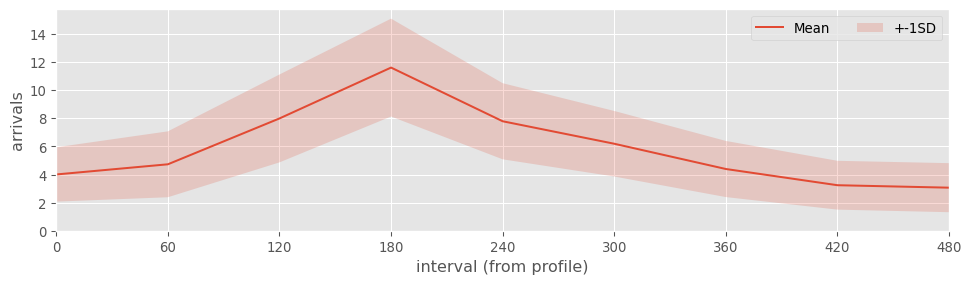

In [8]:
fig, ax = nspp_plot(data, run_length=540)

In [9]:
nspp_replications = nspp_simulation(data, n_reps=1000)

# peak at data
nspp_replications.head()

,0,1,2,3,4,5,6,7,8
rep,,,,,,,,,
1,1,5,7,13,9,11,5,3,1
2,6,7,4,9,6,8,5,1,3
3,3,2,6,13,4,6,2,1,5
4,4,2,8,10,7,7,5,1,9
5,2,4,10,13,10,7,8,4,5


In [10]:
# re-label columns
nspp_replications.columns = data["t"].values


## banks data converted from arrivasl per min to arrivals per hour
data["expected_mean_arrivals_hr"] = data["arrival_rate"] * 60.0
data["simulated_mean_arrivals_hr"] = nspp_replications.mean(axis=0).values
data.round(1)

,t,mean_iat,arrival_rate,expected_mean_arrivals_hr,simulated_mean_arrivals_hr
0,0,15,0.1,4.0,4.0
1,60,12,0.1,5.0,4.7
2,120,7,0.1,8.6,8.0
3,180,5,0.2,12.0,11.6
4,240,8,0.1,7.5,7.8
5,300,10,0.1,6.0,6.2
6,360,15,0.1,4.0,4.4
7,420,20,0.0,3.0,3.2
8,480,20,0.0,3.0,3.1
